# Лабораторна робота 1 — Дослідження даних з NumPy, Pandas та scikit-learn

**Набір даних:** `kc_house_data.csv`  
**Дозволені бібліотеки:** NumPy, Pandas, Matplotlib, scikit-learn (усі модулі)

## Налаштування — встановлення залежностей та імпорт

Запустіть комірку нижче один раз, щоб переконатись, що всі необхідні пакети встановлені.

In [1]:
# Встановлення залежностей (можна запускати повторно)
import sys
!{sys.executable} -m pip install numpy pandas matplotlib scikit-learn --quiet


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)


---
## Завдання 1 — Розминка з NumPy

**а)** Створіть масив NumPy з 10 000 значень, що підпорядковані нормальному розподілу N(0, 1). Обчисліть середнє, стандартне відхилення, мінімум і максимум за допомогою функцій NumPy — **без Python-циклів**.

**б)** Підрахуйте, скільки значень виходять за межі ±2 стандартних відхилення, використовуючи логічну індексацію. Яка це відсоткова частка? Порівняйте з теоретичним значенням ≈4,55 %.

In [13]:
# Завдання 1а — створіть масив і обчисліть статистику
np.random.seed(51)
arr = np.random.randn(10000)

mean_val = np.mean(arr)
std_val  = np.std(arr)
min_val  = np.min(arr)
max_val  = np.max(arr)

print(f"Середнє:            {mean_val:.4f}")
print(f"Стандартне відх.:   {std_val:.4f}")
print(f"Мінімум:            {min_val:.4f}")
print(f"Максимум:           {max_val:.4f}")

Середнє:            0.0110
Стандартне відх.:   1.0027
Мінімум:            -3.7394
Максимум:           4.2048


In [15]:
# Завдання 1б — підрахуйте викиди за допомогою логічної індексації
outliers_mask = np.abs(arr) > 2 * std_val
n_outliers    = np.sum(outliers_mask)
p_outliers  = n_outliers / len(arr) * 100

print(f"Кількість викидів (|x| > 2σ): {n_outliers}")
print(f"Відсоток:                      {p_outliers:.2f}%")
print(f"Теоретичне значення:           ~4.55%")

Кількість викидів (|x| > 2σ): 489
Відсоток:                      4.89%
Теоретичне значення:           ~4.55%


**Ваша відповідь (б):** *Наш відсоток 4.89 майже дорінює теоретичному значенню 4.55. Це означає що ми все зробили коректно*


---
## Завдання 2 — Завантаження та огляд набору даних

Завантажте `kc_house_data.csv` у Pandas DataFrame та дайте відповідь на питання нижче, написавши код:

1. Скільки рядків і стовпців у наборі даних?
2. Які мінімум, максимум, середнє та медіана цін на будинки?
3. Скільки унікальних поштових індексів є у наборі даних? Який поштовий індекс має найбільше оголошень?

In [18]:
# Завантаження набору даних
sales = pd.read_csv('kc_house_data.csv')
sales.head()


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [20]:
# 2-і) Скільки рядків і стовпців?
rows, cols = sales.shape
print(f"Рядків:   {rows}")
print(f"Стовпців: {cols}")

Рядків:   21613
Стовпців: 21


In [22]:
# 2-іі) Мінімум, максимум, середнє та медіана ціни
price_stats = sales['price'].agg(['min', 'max', 'mean', 'median'])
print(f"Мінімум:  ${price_stats['min']:,.0f}")
print(f"Максимум: ${price_stats['max']:,.0f}")
print(f"Середнє:  ${price_stats['mean']:,.0f}")
print(f"Медіана:  ${price_stats['median']:,.0f}")

Мінімум:  $75,000
Максимум: $7,700,000
Середнє:  $540,088
Медіана:  $450,000


In [24]:
# 2-ііі) Кількість унікальних поштових індексів; індекс з найбільшою кількістю оголошень
n_unique_zips = sales['zipcode'].nunique()
top_zip       = sales['zipcode'].value_counts().idxmax()
top_zip_count = sales['zipcode'].value_counts().max()

print(f"Унікальних поштових індексів: {n_unique_zips}")
print(f"Найпопулярніший індекс:       {top_zip} ({top_zip_count} оголошень)")

Унікальних поштових індексів: 70
Найпопулярніший індекс:       98103 (602 оголошень)


---
## Завдання 3 — Візуалізація даних

Створіть **два графіки поруч**:

- **Лівий:** гістограма `price` (50 інтервалів, логарифмічна шкала по осі X).
- **Правий:** діаграма розсіювання `sqft_living` vs `price`, де кольором точок позначено `bedrooms`. Додайте підписи осей і colorbar.

Одним реченням для кожного графіка опишіть, що ви спостерігаєте.

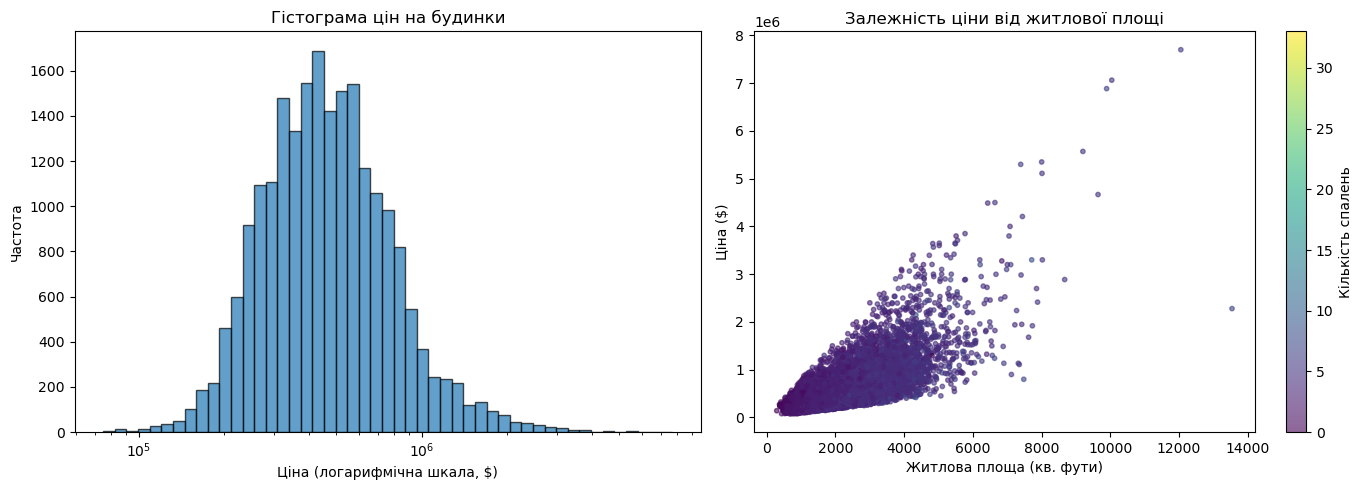

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Завдання 3 — лівий графік: гістограма ціни
bins = np.logspace(np.log10(sales['price'].min()), np.log10(sales['price'].max()), 50)
axes[0].hist(sales['price'], bins=bins, edgecolor='black', alpha=0.7)
axes[0].set_xscale('log')
axes[0].set_title('Гістограма цін на будинки')
axes[0].set_xlabel('Ціна (логарифмічна шкала, $)')
axes[0].set_ylabel('Частота')

# Завдання 3 — правий графік: діаграма розсіювання sqft_living vs price
sc = axes[1].scatter(sales['sqft_living'], sales['price'], c=sales['bedrooms'], cmap='viridis', alpha=0.6, s=10)
axes[1].set_title('Залежність ціни від житлової площі')
axes[1].set_xlabel('Житлова площа (кв. фути)')
axes[1].set_ylabel('Ціна ($)')
cbar = fig.colorbar(sc, ax=axes[1])
cbar.set_label('Кількість спалень')

plt.tight_layout()
plt.show()


**Спостереження (лівий графік):** Гістограма цін на будинки при логарифмічній шкалі на осі X наближається за формою до нормального розподілу з вираженим піком у районі 500,000$, що свідчить про логнормальний розподіл цін у початкових даних.

**Спостереження (правий графік):** Спостерігається чітка позитивна лінійна кореляція між житловою площею (sqft_living) та ціною будинку (price); при цьому будинки з більшою площею зазвичай мають більшу кількість спалень, хоча є поодинокі викиди

---
## Завдання 4 — Навчання та оцінка регресійної моделі

Розбийте дані 80/20 (`random_state=42`). Навчіть `LinearRegression` з scikit-learn для передбачення `price` за єдиною ознакою `sqft_living`.

1. Вкажіть вільний член (intercept) та коефіцієнт для `sqft_living`.
2. Обчисліть MSE і RMSE на тестовій вибірці.
3. Яка передбачувана ціна будинку площею 2 500 кв. футів?

In [37]:
# Поділ на навчальну та тестову вибірки
train_data, test_data = train_test_split(sales, test_size=0.2, random_state=42)


In [45]:
# Завдання 4 — навчіть модель, вкажіть ваги, обчисліть MSE/RMSE, передбачте ціну для 2500 кв. фут.
# Модель 1: одна ознака — sqft_living
model1 = LinearRegression()
model1.fit(train_data[['sqft_living']], train_data['price'])

# Передбачення на тестовій вибірці
y_pred1 = model1.predict(test_data[['sqft_living']])

# Метрики
mse1  = mean_squared_error(test_data['price'], y_pred1)
rmse1 = np.sqrt(mse1)

# Передбачення для 2500 кв. фут
price_2500 = model1.predict([[2500]])[0]

print(f"Вільний член (intercept): ${model1.intercept_:,.2f}")
print(f"Коефіцієнт sqft_living:   ${model1.coef_[0]:.2f} за кв. фут")
print(f"MSE(Mean Squared Error - середня квадратична помилка): {mse1:,.2f}")
print(f"RMSE(Root Mean Squared Error - корінь із MSE):        ${rmse1:,.2f}")
print(f"Прогноз для 2 500 кв. фут: ${price_2500:,.2f}")

Вільний член (intercept): $-41,999.19
Коефіцієнт sqft_living:   $279.55 за кв. фут
MSE(Mean Squared Error - середня квадратична помилка): 76,484,977,061.78
RMSE(Root Mean Squared Error - корінь із MSE):        $276,559.17
Прогноз для 2 500 кв. фут: $656,887.76


C:\Users\droma\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


---
## Завдання 5 — Порівняння двох моделей

Навчіть другу `LinearRegression` з ознаками: `sqft_living`, `bedrooms`, `bathrooms`, `yr_built`. Порівняйте RMSE на тестовій вибірці між Моделлю 1 та Моделлю 2. Яке значення нижче? Коротко поясніть чому.

In [47]:
# Завдання 5 — модель з чотирма ознаками та порівняння RMSE
features2 = ['sqft_living', 'bedrooms', 'bathrooms', 'yr_built']

model2 = LinearRegression()
model2.fit(train_data[features2], train_data['price'])

y_pred2 = model2.predict(test_data[features2])
rmse2   = np.sqrt(mean_squared_error(test_data['price'], y_pred2))

print(f"RMSE Моделі 1 (sqft_living):                          ${rmse1:,.2f}")
print(f"RMSE Моделі 2 (sqft_living + bedrooms + bathrooms + yr_built): ${rmse2:,.2f}")
print(f"\nКраща модель: {'Модель 2' if rmse2 < rmse1 else 'Модель 1'} (нижчий RMSE)")

RMSE Моделі 1 (sqft_living):                          $276,559.17
RMSE Моделі 2 (sqft_living + bedrooms + bathrooms + yr_built): $262,985.98

Краща модель: Модель 2 (нижчий RMSE)


**Відповідь:** RMSE Моделі 2 262986 нижчий за RMSE Моделі 1 276559, оскільки додаткові ознаки (`bedrooms`, `bathrooms`, `yr_built`) несуть додаткову інформацію про ціну будинку, яку не може врахувати лише площа — модель краще апроксимує залежність у даних.

---
## ✨ Бонус — Аналіз залишків

Для вашої кращої моделі обчисліть вектор залишків (predicted − actual). Побудуйте гістограму. Чи виглядають залишки нормально розподіленими та центрованими навколо нуля? Що означав би систематичний ненульовий середній залишок?

In [ ]:
# Бонус — аналіз залишків
# ВАШ КОД ТУТ
raise NotImplementedError

**Спостереження:** *замініть цей текст*